,name,cnt_activities,first_act,last_act
0,Achim,3019,5,24023
1,Anna,3081,4024,25050
2,Eva,3204,1950,23017
3,Lisa,2955,9021,30005
4,Luca,3090,5985,27014
5,Manuel,2914,3,20976
6,Nick,3037,4,28026
7,Tim,2920,1,21949
8,Tom,2982,8027,29020
9,UNKNOWN,2803,2,25984


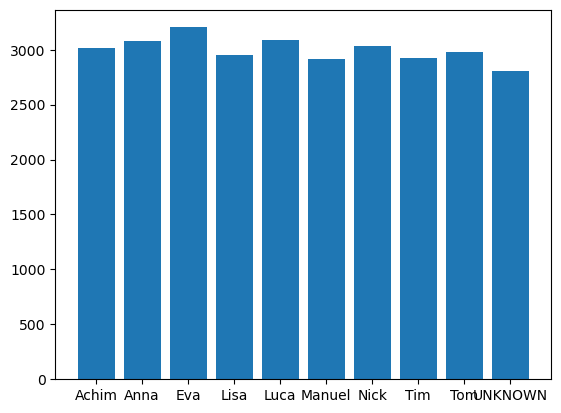

In [14]:
from report import fetch_report
import matplotlib.pyplot as plt

df = fetch_report()
display(df)

plt.bar(df["name"], df["cnt_activities"])
plt.show()


In [8]:
import pandas as pd

# Zusatzspalte: Spannweite der Activity-IDs
df["range_act"] = df["last_act"] - df["first_act"]

per_person = (
    df.sort_values("cnt_activities", ascending=False)
      .assign(avg_id=lambda d: d[["first_act", "last_act"]].mean(axis=1))
      .rename(columns={"cnt_activities": "cnt"})
      .loc[:, ["name", "cnt", "first_act", "last_act", "range_act", "avg_id"]]
)

display(per_person.style.background_gradient(cmap="Blues"))


,name,cnt,first_act,last_act,range_act,avg_id
2,Eva,2136,1950,13017,11067,7483.500000
4,Luca,2060,5985,17014,11029,11499.500000
1,Anna,2054,4024,15050,11026,9537.000000
6,Nick,2025,4,18026,18022,9015.000000
0,Achim,2013,5,14023,14018,7014.000000
8,Tom,1988,8027,19020,10993,13523.500000
3,Lisa,1970,9021,20005,10984,14513.000000
7,Tim,1947,1,11949,11948,5975.000000
5,Manuel,1943,3,10976,10973,5489.500000
9,UNKNOWN,1869,2,15984,15982,7993.000000


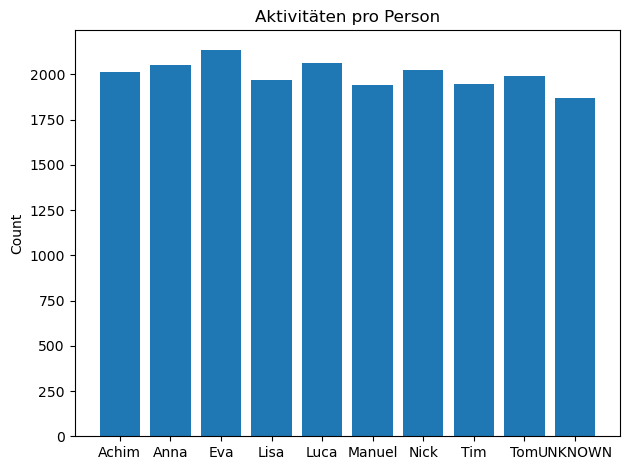

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["name"], df["cnt_activities"])
plt.title("Aktivitäten pro Person")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


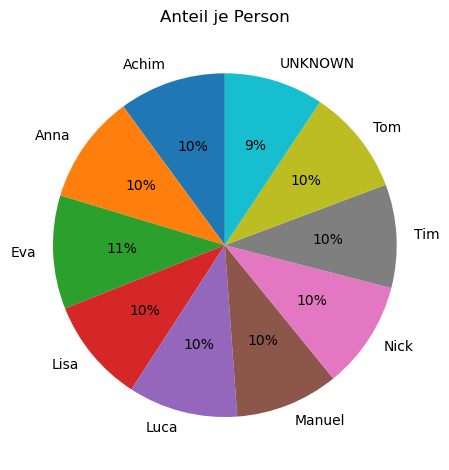

In [11]:
plt.figure()
plt.pie(df["cnt_activities"],
        labels=df["name"],
        autopct="%1.0f%%",
        startangle=90)
plt.title("Anteil je Person")
plt.tight_layout()
plt.show()


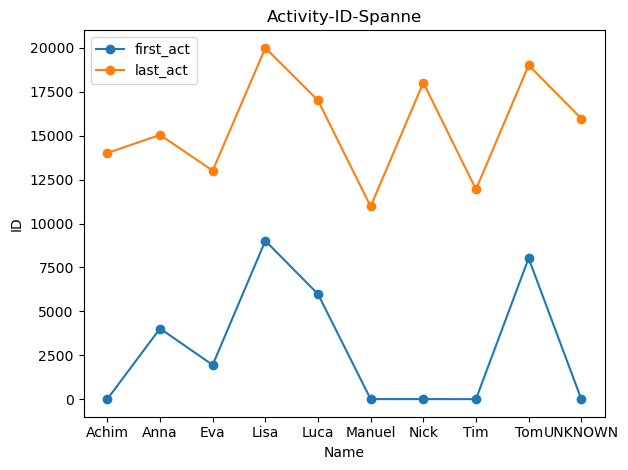

In [12]:
plt.figure()
plt.plot(df["name"], df["first_act"], marker="o", label="first_act")
plt.plot(df["name"], df["last_act"],  marker="o", label="last_act")
plt.title("Activity-ID-Spanne")
plt.xlabel("Name")
plt.ylabel("ID")
plt.legend()
plt.tight_layout()
plt.show()


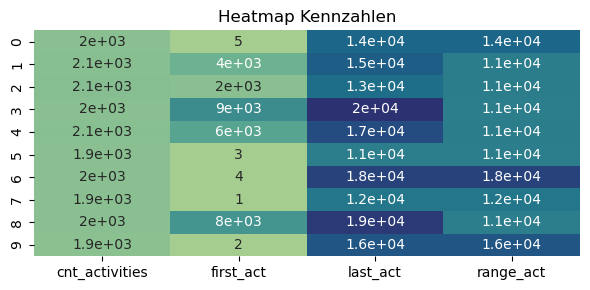

In [13]:
import seaborn as sns  # in Jupyter-Image meist schon installiert

plt.figure(figsize=(6, 3))
sns.heatmap(df.drop("name", axis=1), annot=True, cmap="crest", cbar=False)
plt.title("Heatmap Kennzahlen")
plt.tight_layout()
plt.show()
